<a href="https://colab.research.google.com/github/zoesuhnny/BankCustomerChurnPredictor/blob/main/CustomersChurnPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_recall_curve
import kagglehub

# Download latest version
path = kagglehub.dataset_download("santoshd3/bank-customers")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bank-customers' dataset.
Path to dataset files: /kaggle/input/bank-customers


In [48]:
data = pd.read_csv('/kaggle/input/bank-customers/Churn Modeling.csv')

## Analyze the Data

In [148]:
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


We can see 13 features.  The first practices I typically do is check for missing values and duplicates, especially with user_ids (representing unique individuals).  Additionally, I check how imbalanced the dataset is for the target class ('Exited').

In [149]:
display(data.Exited.value_counts())
churned = data.loc[data.Exited == 1,'Exited'].count()
active = data.loc[data.Exited == 0,'Exited'].count()
percentage_churned = (churned / (active+churned))*100
percentage_churned

,count
Exited,
0,7963
1,2037


np.float64(20.369999999999997)

Around 20.37% of users have churned in this imbalanced dataset.  So we likely will have to tweak our model and training/test data to address that class imbalance.

In [150]:
data.isna().sum()
#No missing values across all columns

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [151]:
data.CustomerId.duplicated().sum()
#No duplicated users

np.int64(0)

## Choose Features

### Surname

In [152]:
data.Surname.value_counts() #2932 unique surnames out of 10,000 total.

,count
Surname,
Smith,32
Scott,29
Martin,29
Walker,28
Brown,26
...,...
Wells,1
Calzada,1
Gresswell,1


In [153]:
surnames, _ = pd.factorize(data.Surname)
#returns tuple of codes (numpy array w/ labels for each unique value) & uniques (array w/ unique values from the original series)
surnames = pd.Series(surnames).astype('float32')
surnames.rename('Surname',inplace=True)
display(surnames)

surnames.nunique() #still 2932 unique surnames, but they're now represented in numerical form.

,Surname
0,0.0
1,1.0
2,2.0
3,3.0
4,4.0
...,...
9995,2539.0
9996,606.0
9997,905.0
9998,1783.0


2932

We convert the surnames series from string values to numerical types (floats), as ML models can only compute using numbers, not strings.

### Geography and Gender

We can use .map() to map a dictionary of values to change the string values in each feature to floats, because the number of unique values in Geography and Gender are manageable enough to create a dictionary out of, unlike Surnames.

For instance, Geography has only 3 unique values (France, Germany, Spain), so making a dictionary to map numbers to their string values is not lengthy to code.

In [154]:
display(data.Geography.value_counts())
countries_mapping = {'France': 0, 'Germany': 1, 'Spain': 2}
countries = data.Geography.map(countries_mapping).astype('float32')
countries

,count
Geography,
France,5014
Germany,2509
Spain,2477


,Geography
0,0.0
1,2.0
2,0.0
3,0.0
4,2.0
...,...
9995,0.0
9996,0.0
9997,0.0
9998,1.0


In [155]:
display(data.Gender.value_counts())
gender_mapping = {'Male': 0, 'Female': 1}
genders = data.Gender.map(gender_mapping).astype('float32')
genders

,count
Gender,
Male,5457
Female,4543


,Gender
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
9995,0.0
9996,0.0
9997,1.0
9998,0.0


### Other Features

In [156]:
#get all other features that just need to change to type 'float32'
other_features = data.loc[:,['CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary']].astype('float32')
other_features

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619.0,42.0,2.0,0.000000,1.0,1.0,1.0,101348.882812
1,608.0,41.0,1.0,83807.859375,1.0,0.0,1.0,112542.578125
2,502.0,42.0,8.0,159660.796875,3.0,1.0,0.0,113931.570312
3,699.0,39.0,1.0,0.000000,2.0,0.0,0.0,93826.632812
4,850.0,43.0,2.0,125510.820312,1.0,1.0,1.0,79084.101562
...,...,...,...,...,...,...,...,...
9995,771.0,39.0,5.0,0.000000,2.0,1.0,0.0,96270.640625
9996,516.0,35.0,10.0,57369.609375,1.0,1.0,1.0,101699.773438
9997,709.0,36.0,7.0,0.000000,1.0,0.0,1.0,42085.578125
9998,772.0,42.0,3.0,75075.312500,2.0,1.0,0.0,92888.523438


In [157]:
features = pd.concat([other_features,surnames,countries,genders],axis=1)
features

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Surname,Geography,Gender
0,619.0,42.0,2.0,0.000000,1.0,1.0,1.0,101348.882812,0.0,0.0,1.0
1,608.0,41.0,1.0,83807.859375,1.0,0.0,1.0,112542.578125,1.0,2.0,1.0
2,502.0,42.0,8.0,159660.796875,3.0,1.0,0.0,113931.570312,2.0,0.0,1.0
3,699.0,39.0,1.0,0.000000,2.0,0.0,0.0,93826.632812,3.0,0.0,1.0
4,850.0,43.0,2.0,125510.820312,1.0,1.0,1.0,79084.101562,4.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771.0,39.0,5.0,0.000000,2.0,1.0,0.0,96270.640625,2539.0,0.0,0.0
9996,516.0,35.0,10.0,57369.609375,1.0,1.0,1.0,101699.773438,606.0,0.0,0.0
9997,709.0,36.0,7.0,0.000000,1.0,0.0,1.0,42085.578125,905.0,0.0,1.0
9998,772.0,42.0,3.0,75075.312500,2.0,1.0,0.0,92888.523438,1783.0,1.0,0.0


## Prepare Data

In [158]:
x_data = features.values.astype('float32')
y_data = data.Exited.values.astype('float32')
x_data.shape, y_data.shape #10,000 examples, with 11 features.

((10000, 11), (10000,))

In [159]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [160]:
x_train,x_test,y_train,y_test = train_test_split(x_data,y_data,test_size=0.2,random_state=42)

In [161]:
#scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [162]:
#convert to tensors
x_train = torch.from_numpy(x_train)
x_test = torch.from_numpy(x_test)
y_train = torch.from_numpy(y_train)
y_test = torch.from_numpy(y_test)

## Create the Model

In [163]:
class LogisticRegression(torch.nn.Module):
  def __init__(self,input_size):
    super(LogisticRegression,self).__init__()
    self.linear1 = torch.nn.Linear(input_size,4)
    self.linear2 = torch.nn.Linear(4,1)
    self.relu = torch.nn.ReLU()

  def forward(self,x):
    return self.linear2(self.relu(self.linear1(x)))

In [164]:
churn_predictor = LogisticRegression(x_train.shape[1]) #number of features is input_size
churn_predictor.to(device)

LogisticRegression(
  (linear1): Linear(in_features=11, out_features=4, bias=True)
  (linear2): Linear(in_features=4, out_features=1, bias=True)
  (relu): ReLU()
)

## Define Loss Function & Optimizer

In [165]:
loss_fn = torch.nn.BCEWithLogitsLoss()
#we don't apply sigmoid transformation in model, since loss_fn takes logits as inputs, not probabilities.
optimizer = torch.optim.Adam(churn_predictor.parameters(),lr=0.08)

churn_predictor.state_dict() #look at weights & bias values for each layer.

OrderedDict([('linear1.weight',
              tensor([[-0.1279,  0.2344,  0.1163,  0.2969, -0.1969,  0.0563, -0.1618,  0.0786,
                       -0.0666, -0.1781, -0.0623],
                      [ 0.2796, -0.2700,  0.1737, -0.1621, -0.1945, -0.0322, -0.2965, -0.0493,
                       -0.2539, -0.2580,  0.2806],
                      [ 0.0709, -0.1643, -0.0767,  0.1450, -0.0601,  0.2023, -0.0190,  0.1026,
                        0.2722, -0.1697,  0.0373],
                      [-0.1899,  0.0208, -0.1820, -0.2445,  0.0552, -0.1867, -0.0808,  0.1589,
                        0.0779,  0.2195, -0.2605]], device='cuda:0')),
             ('linear1.bias',
              tensor([ 0.0386, -0.2721, -0.1058, -0.2290], device='cuda:0')),
             ('linear2.weight',
              tensor([[ 0.2513, -0.3297,  0.4289, -0.1507]], device='cuda:0')),
             ('linear2.bias', tensor([-0.2725], device='cuda:0'))])

In [166]:
#create dataloaders for training and test sets
from torch.utils.data import DataLoader, TensorDataset
batch=200

train_dl = DataLoader(TensorDataset(x_train,y_train),batch,shuffle=True)
test_dl = DataLoader(TensorDataset(x_test,y_test),batch,shuffle=True)

In [167]:
#One forward pass on first 5 training examples, before training the model:
torch.sigmoid(churn_predictor(x_train[:5].to(device)))

tensor([[0.4333],
        [0.4513],
        [0.4386],
        [0.4774],
        [0.5205]], device='cuda:0', grad_fn=<SigmoidBackward0>)

These are not probabilities with definitive answers (close to 0 or 1), but this is prior to training.  We can do forward passes after training the model to see how these probabilities have changed.

## Train the Model

In [168]:
loss_hist = []
epochs = 30

for epoch in range(epochs):
    loss_g = 0

    for xb,yb in train_dl: #for each batch
      outputs = churn_predictor(xb.to(device))
      loss = loss_fn(outputs,yb.unsqueeze(1).to(device))

      loss.backward() #compute gradients (backpropagation)
      optimizer.step() #update loss w/ gradients, to minimize loss
      optimizer.zero_grad() #zero out gradients, to avoid accumulation of gradients in calculations
      loss_g += loss.item() #add loss to loss_g, which will be added after every epoch to loss_hist.

    if (epoch + 1) % 10 == 0:
      print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss_g/len(train_dl):.4f}')
      loss_hist.append(loss_g)
    loss_g=0

Epoch [10/30], Loss: 0.3621
Epoch [20/30], Loss: 0.3596
Epoch [30/30], Loss: 0.3594


To train further, we can change the learning rate, and the number of epochs, as we go. Let's create this training loop as a function to minimize repetitive code.

I replaced the optimizer code from before to be overridden by the code within this function, but I still presented it before for the sake of showing that I am using the Adam optimizer.

In [169]:
loss_hist = []

def training_loop(epochs,learning_r):
  #update optimizer with chosen learning rate, lr
  optimizer = torch.optim.Adam(churn_predictor.parameters(),lr=learning_r)

  for epoch in range(epochs):
    loss_g = 0

    for xb,yb in train_dl: #for each batch
      outputs = churn_predictor(xb.to(device))
      loss = loss_fn(outputs,yb.unsqueeze(1).to(device))

      loss.backward() #compute gradients (backpropagation)
      optimizer.step() #update loss w/ gradients, to minimize loss
      optimizer.zero_grad() #zero out gradients, to avoid accumulation of gradients in calculations
      loss_g += loss.item() #add loss to loss_g, which will be added after every epoch to loss_hist.

    if (epoch + 1) % 10 == 0:
      print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss_g/len(train_dl):.4f}')
      loss_hist.append(loss_g)
    loss_g=0

In [170]:
training_loop(200,0.01)

Epoch [10/200], Loss: 0.3500
Epoch [20/200], Loss: 0.3483
Epoch [30/200], Loss: 0.3471
Epoch [40/200], Loss: 0.3459
Epoch [50/200], Loss: 0.3456
Epoch [60/200], Loss: 0.3456
Epoch [70/200], Loss: 0.3448
Epoch [80/200], Loss: 0.3449
Epoch [90/200], Loss: 0.3451
Epoch [100/200], Loss: 0.3447
Epoch [110/200], Loss: 0.3448
Epoch [120/200], Loss: 0.3451
Epoch [130/200], Loss: 0.3454
Epoch [140/200], Loss: 0.3450
Epoch [150/200], Loss: 0.3443
Epoch [160/200], Loss: 0.3450
Epoch [170/200], Loss: 0.3448
Epoch [180/200], Loss: 0.3445
Epoch [190/200], Loss: 0.3446
Epoch [200/200], Loss: 0.3444


## Evaluate the Model

In [171]:
churn_predictor.eval()
preds = []
targets = []
probs = []

with torch.no_grad():
  for xb, yb in test_dl:
    probability = torch.sigmoid(churn_predictor(xb.to(device))) #logit -> probability via sigmoid transformation.
    prediction = torch.round(probability) #rounds probabilities to either 0 (active) or 1 (churned).

    #record results to lists
    probs.extend(probability.cpu().numpy())
    preds.extend(prediction.cpu().numpy())
    targets.extend(yb.cpu().numpy())

print(classification_report(preds,targets,target_names = ['Active','Churned']))

              precision    recall  f1-score   support

      Active       0.96      0.88      0.92      1763
     Churned       0.44      0.73      0.55       237

    accuracy                           0.86      2000
   macro avg       0.70      0.80      0.73      2000
weighted avg       0.90      0.86      0.87      2000



### PR-AUC and ROC-AUC

### Precision-Recall Curve

Precision-Recall AUC: 0.6401
ROC AUC: 0.8472


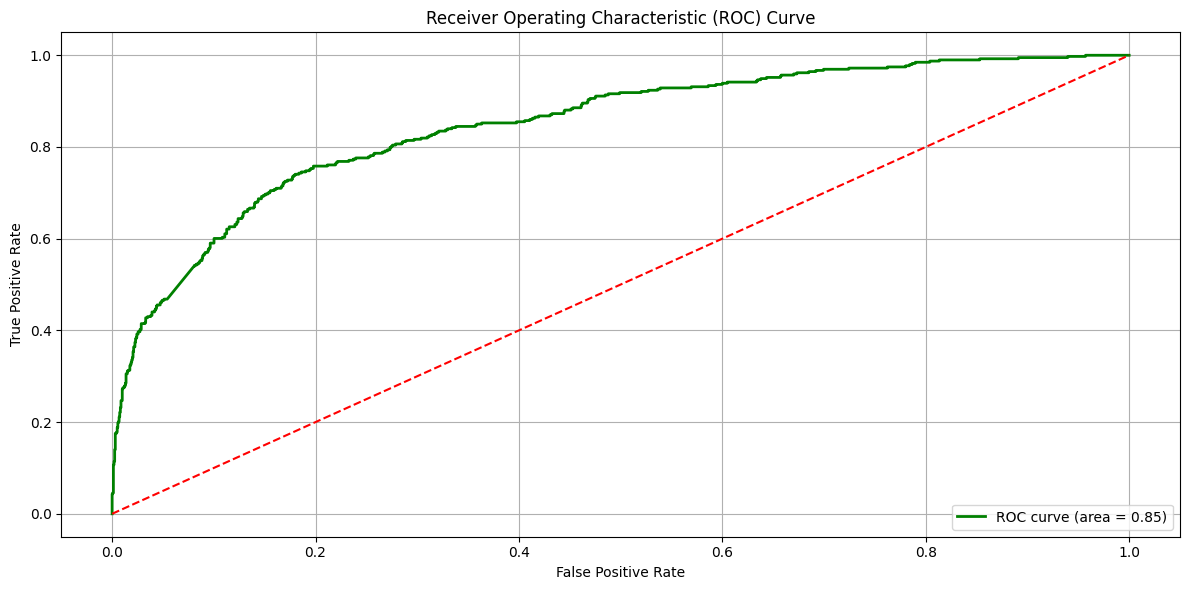

In [172]:
from sklearn.metrics import auc, roc_curve, roc_auc_score

precisions, recalls, thresholds = precision_recall_curve(targets,preds)
pr_auc = auc(recalls, precisions)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

#ROC-AUC
roc_auc = roc_auc_score(targets, probs)
print(f"ROC AUC: {roc_auc:.4f}")

#PR-ROC curve
fpr, tpr, thresholds_roc = roc_curve(targets, probs)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

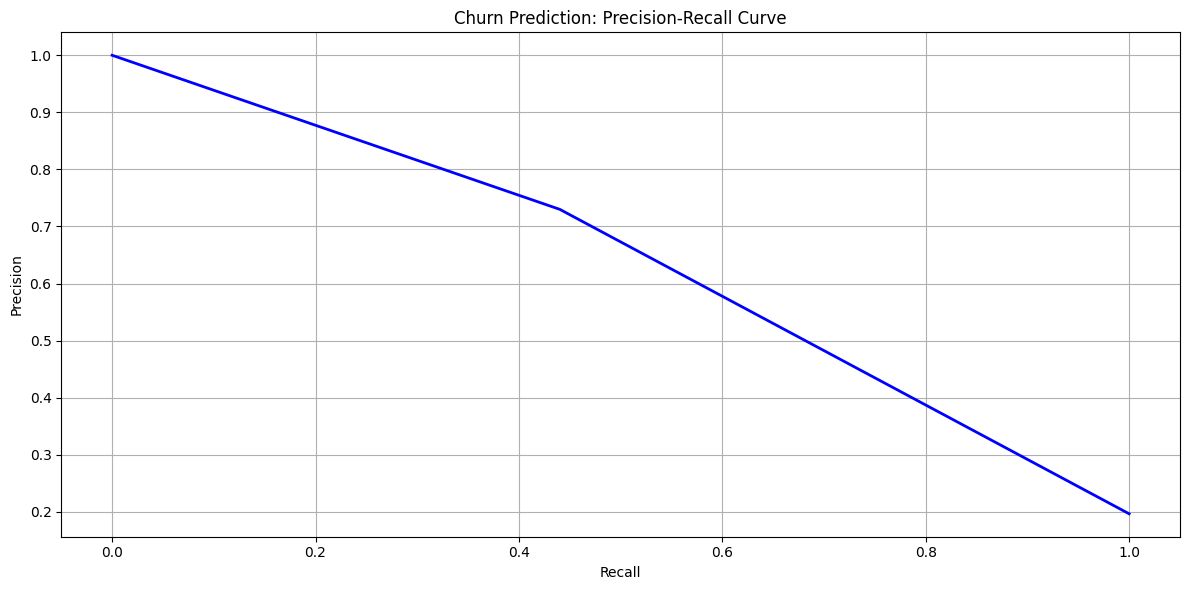

In [173]:
precisions, recalls, thresholds = precision_recall_curve(targets,preds)

plt.figure(figsize=(12, 6))
plt.plot(recalls, precisions, color='blue', lw=2, label='PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Churn Prediction: Precision-Recall Curve')
plt.grid(True)
plt.tight_layout()
plt.show()

### Explain the Evaluation Metrics

    Trial #1:
                  precision    recall  f1-score   support

      Active       0.96      0.88      0.92      1746
     Churned       0.46      0.72      0.56       254

    accuracy                           0.86      2000


Accuracy is less important to analyze than precision and recall, since this is an imbalanced dataset.  Accuracy may only be high because the model is more comfortable guessing 'active' for most customers since a majority of the data is comprised of active customers, not churned.

For the churned class, the high recall means the model catches **88%** of all customers that are churned.  The low precision means only **46%** of the model’s predictions for the churned class, are actually correct.  In other words, although the model correctly predicts many of the actual churned customers as churned, by doing so, the model is flagging too many customers as falsely churned when they are active.

The ROC-AUC score is initially 0.8550, meaning that a random churned customer ranks higher than a random active user **85.5%** of the time.  It’s overall good at separating churned cases from active cases.

The precision-recall AUC score of 0.6426 means the model is struggling with false positives, which often happens with far fewer churned (positive) cases in the data than active data.

To fix this, we can make the **model more strict in when it predicts a customer as churned.**  In other words, we have to reduce the number of predicted false positives.  

We can increase the **threshold** from 0.5 to 0.7, as a threshold means the probability must be of a stronger magnitude (above the threshold) in order for it to be classified as ‘churned.,’ and rounded to 1.


### Calculate Youden's J Statistics

Youden's J Statistic will help us find the best threshold to set our model.  In short, J = Sensitivity+Specificity-1 = Sensitivity - (1 - False Positive Rate) + 1 = True Positive Rate - False Positive Rate.  We choose the threshold with the largest J.

In [174]:
#fpr, tpr, thresholds_roc = roc_curve(targets, probs)
J = tpr - fpr
threshold = thresholds_roc[np.argmax(J)] #gets largest value in J
threshold

np.float32(0.24485338)

We'll have to re-calculate this later, since we will be cutting off some features.

## Feature Importance

In [175]:
weights = churn_predictor.linear1.weight.cpu().detach().numpy() #detach and move to CPU for numpy compatibility
print(weights.shape,'\n') #(4 output neurons, features)

feature_names = features.columns
feature_importance = np.mean(np.abs(weights), axis=0) #calculate the mean absolute weight for each feature

importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importance}).sort_values(by='Importance',ascending=False)

print(importance_df)

(4, 11) 

            Feature  Importance
4     NumOfProducts    2.655888
9         Geography    1.514341
6    IsActiveMember    1.461935
1               Age    1.332586
3           Balance    0.700003
10           Gender    0.259665
8           Surname    0.161219
5         HasCrCard    0.087349
2            Tenure    0.082084
0       CreditScore    0.054979
7   EstimatedSalary    0.033310


### Record of Feature Importance Scores

Feature  Importance


4     NumOfProducts    3.270595

6    IsActiveMember    2.092465

9         Geography    1.368978

1               Age    1.151658

3           Balance    0.542494

10           Gender    0.206325

8           Surname    0.108607

7   EstimatedSalary    0.090213

5         HasCrCard    0.079444

2            Tenure    0.073988

0       CreditScore    0.064201

---


We can also try to remove some unimportant features, to see if that helps the predicting power of the model.  We at least know to keep NumOfProducts, IsActiveMember, Geography, and Age.

## Tweaking the Model

### Cut Some Features

In [176]:
features.drop(columns=['CreditScore','Tenure'],inplace=True)
features.head()

,Age,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Surname,Geography,Gender
0,42.0,0.000000,1.0,1.0,1.0,101348.882812,0.0,0.0,1.0
1,41.0,83807.859375,1.0,0.0,1.0,112542.578125,1.0,2.0,1.0
2,42.0,159660.796875,3.0,1.0,0.0,113931.570312,2.0,0.0,1.0
3,39.0,0.000000,2.0,0.0,0.0,93826.632812,3.0,0.0,1.0
4,43.0,125510.820312,1.0,1.0,1.0,79084.101562,4.0,2.0,1.0


### Re-create Dataloaders and Model

In [177]:
x_data = features.values.astype('float32')
y_data = data.Exited.values.astype('float32')
x_data.shape, y_data.shape #10,000 examples, with 11 features.

x_train,x_test,y_train,y_test = train_test_split(x_data,y_data,test_size=0.2,random_state=42)

#scale the data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#convert to tensors
x_train = torch.from_numpy(x_train)
x_test = torch.from_numpy(x_test)
y_train = torch.from_numpy(y_train)
y_test = torch.from_numpy(y_test)

In [178]:
churn_predictor = LogisticRegression(x_train.shape[1]) #number of features is input_size
churn_predictor.to(device)

#Loss Function and Optimizer
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(churn_predictor.parameters(),lr=0.08)

#create dataloaders for training and test sets
from torch.utils.data import DataLoader, TensorDataset
batch=200

train_dl = DataLoader(TensorDataset(x_train,y_train),batch,shuffle=True)
test_dl = DataLoader(TensorDataset(x_test,y_test),batch,shuffle=True)

### Train the Model

In [179]:
loss_hist = []
training_loop(30,0.08)
training_loop(200,0.01)


Epoch [10/30], Loss: 0.4117
Epoch [20/30], Loss: 0.4109
Epoch [30/30], Loss: 0.4094
Epoch [10/200], Loss: 0.4010
Epoch [20/200], Loss: 0.4001
Epoch [30/200], Loss: 0.3999
Epoch [40/200], Loss: 0.4004
Epoch [50/200], Loss: 0.4002
Epoch [60/200], Loss: 0.4004
Epoch [70/200], Loss: 0.4004
Epoch [80/200], Loss: 0.3995
Epoch [90/200], Loss: 0.3999
Epoch [100/200], Loss: 0.4005
Epoch [110/200], Loss: 0.3999
Epoch [120/200], Loss: 0.4005
Epoch [130/200], Loss: 0.3994
Epoch [140/200], Loss: 0.3996
Epoch [150/200], Loss: 0.4000
Epoch [160/200], Loss: 0.3996
Epoch [170/200], Loss: 0.3995
Epoch [180/200], Loss: 0.3994
Epoch [190/200], Loss: 0.3999
Epoch [200/200], Loss: 0.3994


## Evaluate the Model

In [180]:
precisions, recalls, thresholds = precision_recall_curve(targets,preds)
pr_auc = auc(recalls, precisions)
fpr, tpr, thresholds_roc = roc_curve(targets, probs)

In [181]:
#KEY: CALCULATE YOUDEN'S STATISTIC (J)
J = tpr - fpr
threshold = thresholds_roc[np.argmax(J)] #gets largest value of J.
threshold

np.float32(0.24485338)

In [182]:
churn_predictor.eval()
preds = []
targets = []
probs = []

with torch.no_grad():
  for xb, yb in test_dl:
    probability = torch.sigmoid(churn_predictor(xb.to(device))) #logit -> probability via sigmoid transformation.

    prediction = (probability > threshold).int()
    #APPLIED THRESHOLD: if condition is true (passes threshold), rounds to 1 (churned).

    #record results to lists
    probs.extend(probability.cpu().numpy())
    preds.extend(prediction.cpu().numpy())
    targets.extend(yb.cpu().numpy())

print(classification_report(preds,targets,target_names = ['Active','Churned']))

              precision    recall  f1-score   support

      Active       0.79      0.91      0.85      1395
     Churned       0.69      0.45      0.54       605

    accuracy                           0.77      2000
   macro avg       0.74      0.68      0.69      2000
weighted avg       0.76      0.77      0.75      2000



In [183]:
weights = churn_predictor.linear1.weight.cpu().detach().numpy() #detach and move to CPU for numpy compatibility
print(weights.shape,'\n') #(4 output neurons, features)

feature_names = features.columns
feature_importance = np.mean(np.abs(weights), axis=0) #calculate the mean absolute weight for each feature

importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importance}).sort_values(by='Importance',ascending=False)

print(importance_df)

(4, 9) 

           Feature  Importance
0              Age    1.724365
4   IsActiveMember    1.672285
7        Geography    1.596911
1          Balance    0.390950
5  EstimatedSalary    0.223584
8           Gender    0.200736
6          Surname    0.178931
2    NumOfProducts    0.123434
3        HasCrCard    0.114443
